In [ ]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk
from rprint import rprint

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


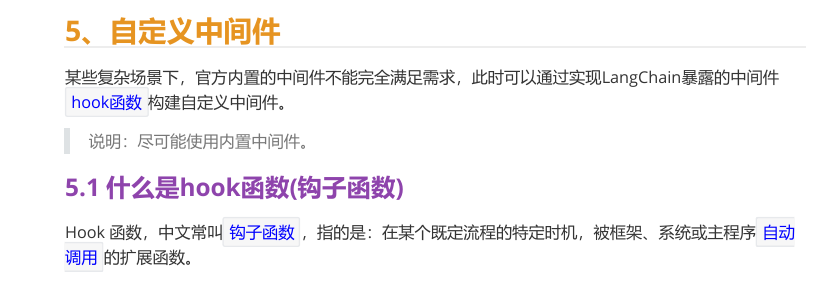
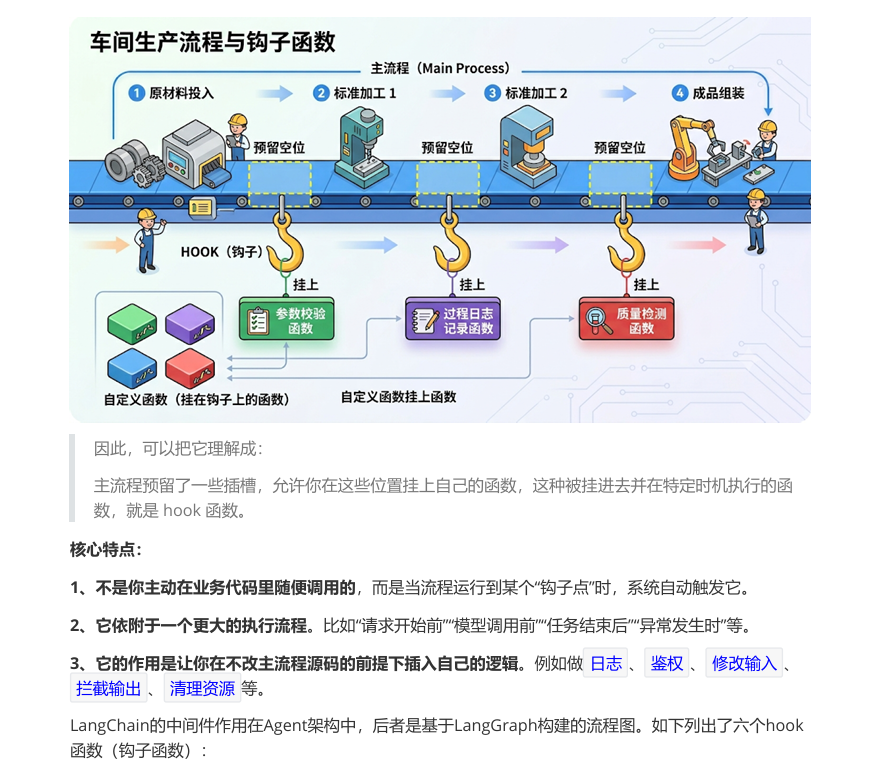

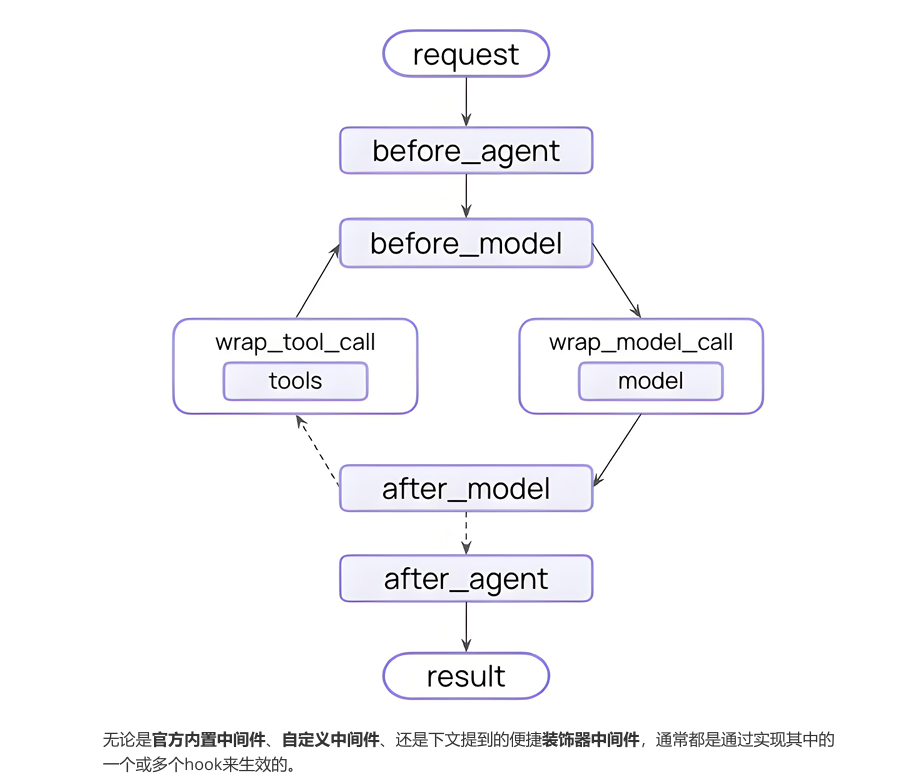

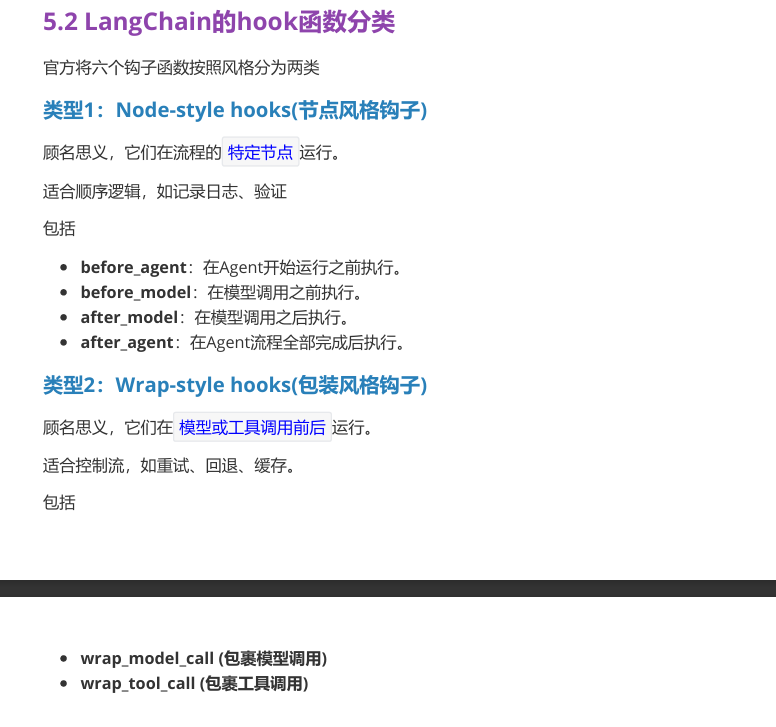

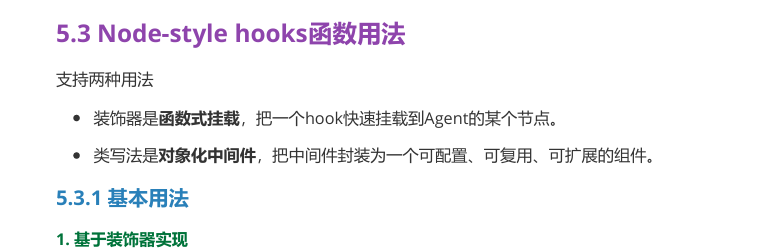

In [ ]:
from langchain.agents.middleware import before_model, after_model, before_agent, after_agent, AgentState, \
    AgentMiddleware
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime
from langchain.agents import create_agent
from typing import Any


# 1. 定义 before_model 钩子
@before_model
def before_model_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_model <- "
    return None


# 2. 定义 after_model 钩子
@after_model
def after_model_middleware(state: AgentState, runtime: Runtime) -> dict[str,
Any] | None:
    state["messages"][-1].content += " -> after_model <- "
    return None


# 3. 定义 before_agent 钩子
@before_agent
def before_agent_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_agent <- "
    return None


# 4. 定义 after_agent 钩子
@after_agent
def after_agent_middleware(state: AgentState, runtime: Runtime) -> None:
    state["messages"][-1].content += " -> after_agent <- "
    return None


agent = create_agent(
    model=model,
    middleware=[before_model_middleware, after_model_middleware,
                before_agent_middleware, after_agent_middleware]  # 👈 添加中间件
)
response = agent.invoke({
    "messages": [HumanMessage("你好啊")],
})
for msg in response["messages"]:
    msg.pretty_print()

1. 观察HumanMessage可以发现，before_agent钩子先于before_model被执行，二者都在调用模型
之前被执行
2. after_agent晚于after_model执行，二者都在模型调用后执行。

2. 基于类实现
关键规则：
1. 必须继承
AgentMiddleware  ← 这个固定
2. 方法名固定 (
before_model ,
3. 类名随意  ← 这个不固定
LangGraph 只看：
after_model )  ← 这个固定
是否继承 AgentMiddleware？
是否有 before_model / after_model 等方法？

In [ ]:
from langchain.agents.middleware import AgentMiddleware
from rich import print as rprint


class CustomMiddleware(AgentMiddleware):

    def before_model(self, state, runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += " ->  [自定义中间件] before_model <- "
        return None

    def after_model(self, state, runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += " ->  [自定义中间件] after_model <- "
        return None

    def before_agent(self, state, runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += " ->  [自定义中间件] before_agent <- "
        return None

    def after_agent(self, state, runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += " ->  [自定义中间件] after_agent <- "
        return None


agent = create_agent(
    model=model,
    middleware=[CustomMiddleware()]  # 👈 添加中间件
)
response = agent.invoke({
    "messages": [HumanMessage("你好啊")],
})
for msg in response["messages"]:
    rprint(msg)


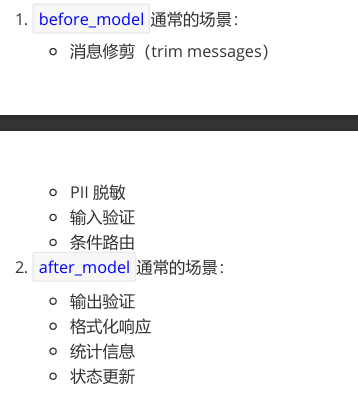
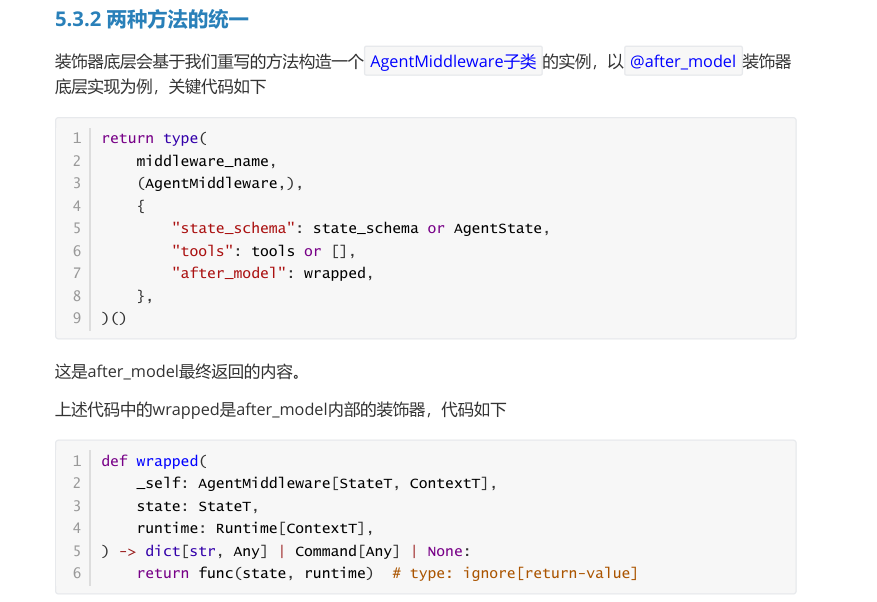
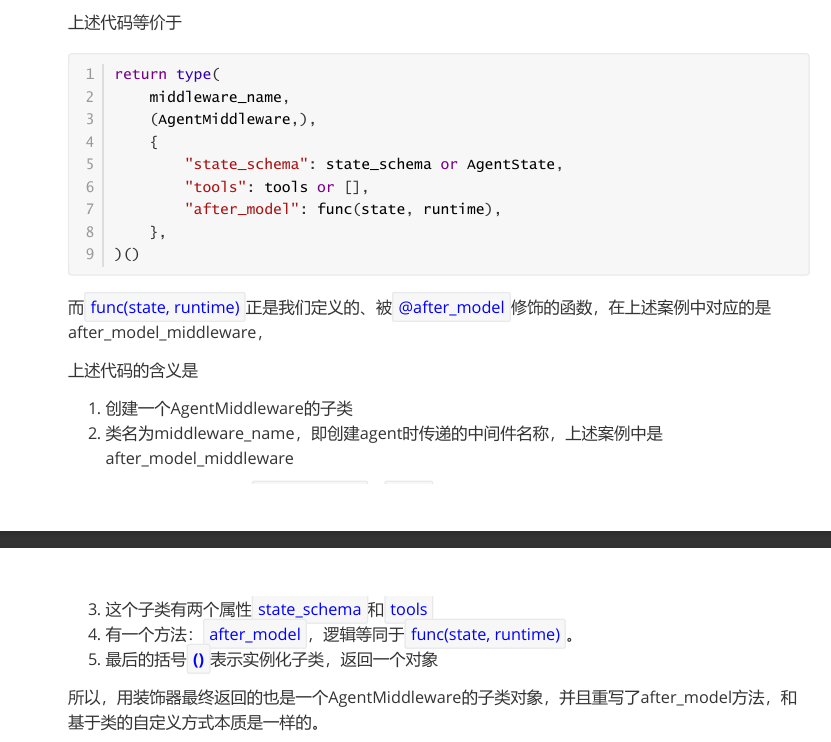
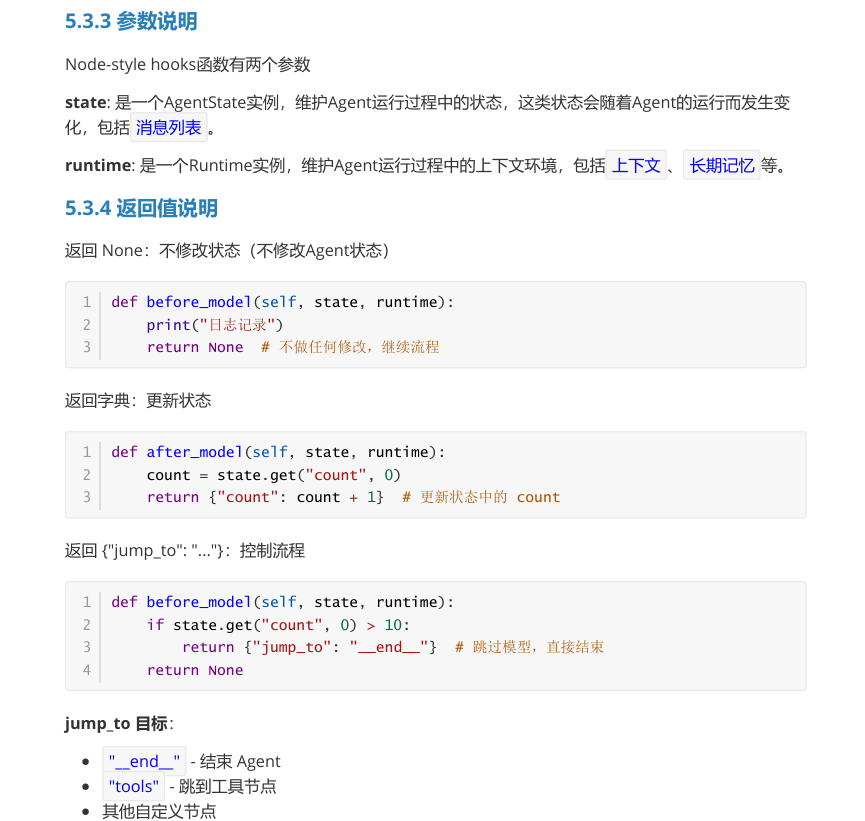
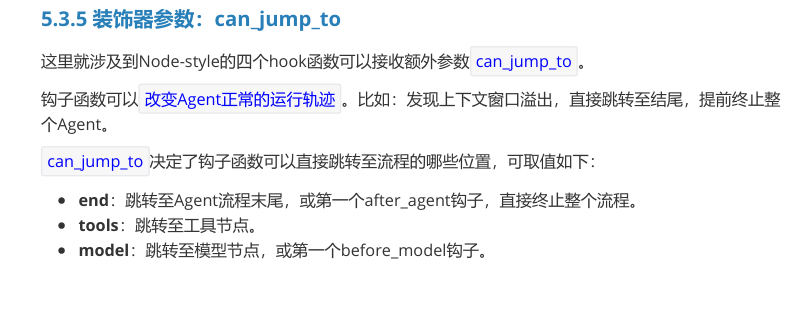

1. 基于装饰器实现

In [18]:
from typing import Any
from langchain.agents import create_agent
from langchain.agents.middleware import before_model, after_model, AgentState
from langchain.messages import AIMessage, SystemMessage
from langchain.tools import tool
from langgraph.runtime import Runtime
from rich import print as rprint


@tool
def get_news() -> str:
    """获取当日新闻"""
    return f"美加墨世界杯今日开幕"


# 在模型（LLM）执行前触发。允许跳转到 "tools" 节点。
@before_model(can_jump_to=["tools"])
def force_tool_first(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
    【业务场景：强行拦截并触发工具】
    如果用户输入包含 "direct tool"，则跳过本次大模型的思考/生成阶段，
    直接伪造一个大模型的 tool_calls 意图，强行把控制权移交给工具执行节点。
    """
    text = state["messages"][-1].content
    # 检查关键词，满足条件则强行干预流程
    if isinstance(text, str) and "direct tool" in text.lower():
        print("[MIDDLEWARE] before_model: jump_to='tools'")
        # 人工构造一个大模型的消息对象（AIMessage）
        # 欺骗系统，让系统误以为这是模型自己决定要调用的工具
        fake_tool_call = AIMessage(
            content="人工构造的消息",
            tool_calls=[
                {
                    "name": "get_news",
                    "args": {},
                    "id": "call_force_weather_001",
                }
            ],
        )
        # 返回更新后的状态：注入伪造的消息，并明确指定下一步跳转到 "tools" 节点
        return {
            "messages": [fake_tool_call],
            "jump_to": "tools",
        }
    # 如果不满足触发条件，返回 None，流程正常向下流转（继续让 LLM 思考）
    return None


# 在模型（LLM）执行生成之后触发。允许重新跳转回 "model" 节点。
@after_model(can_jump_to=["model"])
def retry_with_extra_instruction(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
       【业务场景：反思/重试机制】
       如果大模型已经生成了回答，但发现用户最初的请求包含 "retry model"，
       则动态追加一条系统提示词（SystemMessage），强行让模型重新生成（重试）一次。
       """
    # 倒序遍历消息历史，找到最近的一次用户输入（human 消息）
    user_text = ""
    for msg in reversed(state["messages"]):
        if getattr(msg, "type", "") == "human":
            user_text = getattr(msg, "content", "")
            break
    # 检查用户输入是否包含触发重试的关键字
    if isinstance(user_text, str) and "retry model" in user_text.lower():
        # 【核心防御】：防止无限循环重跳（死循环）
        # 检查消息历史中是否已经注入过这条特殊的系统提示。如果有，说明已经重试过了，不再重复干预。
        already_injected = any(
            isinstance(getattr(msg, "content", None), str)
            and "你必须以【二次回答】开头" in msg.content for msg in state["messages"]
        )
        if already_injected:
            return None  # 已注入过，直接放行，结束重试流程
        print("[MIDDLEWARE] after_model: jump_to='model' with extra system instruction")
        # 返回更新后的状态：追加强力约束的系统消息，并将指针跳回 "model" 节点重新执行
        return {
            "messages": [
                SystemMessage("你必须以【二次回答】开头，并且只用一句话回答。")
            ],
            "jump_to": "model",
        }
    return None


# 在模型（LLM）执行前触发。允许直接跳转到 "end" 节点（强行终止）。
@before_model(can_jump_to=["end"])
def overflow_context_processor(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
    【业务场景：安全卫士/异常拦截】
    模拟上下文窗口溢出（Token超限）或其他严重的系统阻断情况。
    一旦触发，直接熔断流程，拒绝让大模型继续处理，直接报错或返回兜底文案。
    """
    # 假装溢出,模拟检查最后一条消息是否包含 overflow 标识
    if "overflow" in state["messages"][-1].content:
        print("[MIDDLEWARE] before_model: jump_to='end' when contenxtwindowoverflow")
        # 构造兜底的结束消息，并直接指定跳转到 "end" 终止 Agent 运行
        return {
            "messages": [
                AIMessage("上下文窗口溢出，终止")
            ],
            "jump_to": "end",
        }


agent = create_agent(
    model=model,
    tools=[get_news],
    # # 将定义的中间件按照顺序挂载到 Agent 中（注意：执行顺序会严格按照列表声明顺序）
    middleware=[force_tool_first, retry_with_extra_instruction,
                overflow_context_processor],
)


def run_once(user_input: str):
    result = agent.invoke(
        {
            "messages": [
                {"role": "user", "content": user_input}
            ]
        }
    )
    for msg in result["messages"]:
        rprint(msg)


if __name__ == "__main__":
    # Case 1: 直接跳 tools
    # 预期表现：
    # 1. 触发 force_tool_first，打印 "[MIDDLEWARE] before_model:jump_to = 'tools'"
    # 2. 绕过 LLM 的首轮思考，直接调用 `get_news` 工具
    # 3. 工具返回结果后，LLM 总结工具结果并输出

    # print('=' * 30, '-> Case 1 <-', '=' * 30)
    # run_once("请帮我查今日新闻 direct tool")

    # Case 2: 输出后跳回 model
    # 预期表现：
    # 1. 正常进入 LLM 生成第 1 版回答
    # 2. 触发 retry_with_extra_instruction，打印 "[MIDDLEWARE]after_model:jump_to = 'model'..."
    # 3. 注入系统提示词后，LLM 被强行拉回并生成第 2 版回答
    # 4. 最终输出应带有“【二次回答】”前缀

    # print('=' * 30, '-> Case 2 <-', '=' * 30)
    # run_once("请随便介绍一下 LangChain retry model")

    # Case 3:
    # 预期表现：
    # 1. 触发 overflow_context_processor 中间件
    # 2. 直接打印终止信息并退出，LLM 根本不会接收到这个请求

    # print('=' * 30, '-> Case 3 <-', '=' * 30)
    # run_once("你好 overflow")

    # Case 4: 正常流程
    # 预期表现：
    # 1. 没有任何中间件被触发（不满足任何关键字）
    # 2. Agent 走正常的 OOTB（Out of the box）标准工作流：User -> Model -> Call Tool -> Model -> End
    print('=' * 30, '-> Case 4 <-', '=' * 30)
    run_once("今日新闻摘要？")




============================== -> Case 4 <- ==============================


HumanMessage(
    content='今日新闻摘要？',
    additional_kwargs={},
    response_metadata={},
    id='a3266863-2528-4226-8af9-e138e9b470c7'
)

AIMessage(
    content='',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 28,
            'prompt_tokens': 259,
            'total_tokens': 287,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 259
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-v4-flash',
        'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
        'id': '8e182431-0eef-41d6-a6c1-7715f1802cc4',
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='lc_run--019f6f03-e460-7b53-98fe-6b36ff59a204-0',
    tool_calls=[{'name': 'get_news', 'args': {}, 'id': 'call_00_29kh5LMi43hG8JVKxTDj8763', 'type': 'tool_call'}],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 259,
        'output_tokens': 28,
        'total_tokens': 287,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {}
    }
)

ToolMessage(
    content='美加墨世界杯今日开幕',
    name='get_news',
    id='f7a1ccc4-9f3a-485e-8b2e-78f0bdfd990d',
    tool_call_id='call_00_29kh5LMi43hG8JVKxTDj8763'
)

AIMessage(
    content='## 📰 
今日新闻摘要\n\n**2026年美加墨世界杯今日开幕！**\n\n今天最重要的新闻是：**美加墨世界杯正式开幕**！这是历史上首次由
三个国家（美国、加拿大、墨西哥）联合举办的世界杯足球赛，备受全球瞩目。\n\n---\n\n如果您想了解更多细节或对某方面感兴
趣，请告诉我，我可以继续为您查询！⚽',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 80,
            'prompt_tokens': 305,
            'total_tokens': 385,
            'completion_tokens_details': None,
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256},
            'prompt_cache_hit_tokens': 256,
            'prompt_cache_miss_tokens': 49
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-v4-flash',
        'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
        'id': '783e907d-cf89-4852-8c92-beed3e8eaac1',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019f6f03-ea2a-7000-a168-7fd0ab21cb06-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 305,
        'output_tokens': 80,
        'total_tokens': 385,
        'input_token_details': {'cache_read': 256},
        'output_token_details': {}
    }
)

1. 我们提前判定需要调用工具，直接在before_model中跳转至工具节点，省去了一次模型调用
2. 通过约定的retry model标记，在after_model之后再次跳转到模型节点，触发模型重复调用
3. 通过约定的overflow标记，模拟上下文窗口溢出，在before_model中直接跳转至结尾，提前终
止流程
4. Case 4 是没有被干预的正常Agent流程，作为对照

2. 基于类实现
和基于装饰器实现的关键区别在于：需要引入额外的装饰器@hook_config为can_jump_to传参。

In [ ]:
from typing import Any
from langchain.agents import create_agent
from langchain.agents.middleware import hook_config, AgentState, AgentMiddleware
from langchain.messages import AIMessage, SystemMessage
from langchain.tools import tool
from langgraph.runtime import Runtime


@tool
def get_news() -> str:
    """获取当日新闻"""
    return f"美加墨世界杯今日开幕"


class MyMiddleware(AgentMiddleware):

    @hook_config(can_jump_to=["tools", "end"])
    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        text = state["messages"][-1].content
        # 假装溢出
        if "overflow" in text:
            print("[MIDDLEWARE] before_model: jump_to='end' when contenxt window overflow")
            return {
                "messages": [
                    AIMessage("上下文窗口溢出，终止")
                ],
                "jump_to": "end",
            }
        if isinstance(text, str) and "direct tool" in text.lower():
            print("[MIDDLEWARE] before_model: jump_to='tools'")
            fake_tool_call = AIMessage(
                content="人工构造的消息",
                tool_calls=[{
                    "name": "get_news",
                    "args": {},
                    "id": "call_force_weather_001",
                }
                ],
            )
            return {
                "messages": [fake_tool_call],
                "jump_to": "tools",
            }
        return None

    @hook_config(can_jump_to=["model"])
    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        user_text = ""
        for msg in reversed(state["messages"]):
            if getattr(msg, "type", "") == "human":
                user_text = getattr(msg, "content", "")
                break
        if isinstance(user_text, str) and "retry model" in user_text.lower():
            # 防止无限重跳：如果已经加过提示，就不再跳
            already_injected = any(
                isinstance(getattr(msg, "content", None), str)
                and "你必须以【二次回答】开头" in msg.content
                for msg in state["messages"]
            )
            if already_injected:
                return None
            print("[MIDDLEWARE] after_model: jump_to='model' with extra system instruction")
            return {
                "messages": [
                    SystemMessage("你必须以【二次回答】开头，并且只用一句话回答。")
                ],
                "jump_to": "model",
            }
        return None


agent = create_agent(
    model=model,
    tools=[get_news],
    middleware=[MyMiddleware()],
)


def run_once(user_input: str):
    result = agent.invoke({"messages": [
        {"role": "user", "content": user_input}
    ]
    })
    for msg in result["messages"]:
        msg.pretty_print()


if __name__ == "__main__":
    # Case 1: 直接跳 tools
    print('=' * 30, '-> Case 1 <-', '=' * 30)
    run_once("请帮我查今日新闻 direct tool")
    # Case 2: 输出后跳回 model
    print('=' * 30, '-> Case 2 <-', '=' * 30)
    run_once("请随便介绍一下 LangChain retry model")
    # Case 3:
    print('=' * 30, '-> Case 3 <-', '=' * 30)
    run_once("你好 overflow")
    # Case 4: 正常流程
    print('=' * 30, '-> Case 4 <-', '=' * 30)
    run_once("今日新闻摘要？")

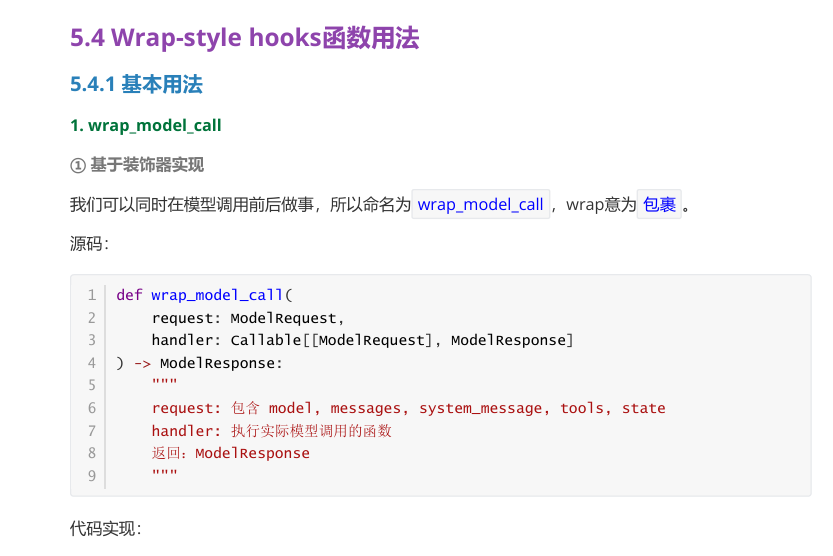

In [19]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain.messages import HumanMessage
from langchain.agents import create_agent
from typing import Callable


@wrap_model_call
def wrap_model_call_middleware(
        request: ModelRequest,  # 包含即将发送给大模型的所有请求数据（如消息列表、温度等）
        handler: Callable[[ModelRequest], ModelResponse],  # 核心句柄：代表下一个中间件或最终的大模型调用服务
) -> ModelResponse | None:
    # 动态篡改用户发出的最后一条消息的内容，悄悄往里面追加字符串。
    # 典型应用：统一在底层为所有请求追加特殊的 Prompt 提示词（例如：“请用中文回答”、“禁止透漏公司机密”等）。
    request.messages[-1].content += " -> wrap_model_call_before <- "
    # 将修改后的请求传递给 handler，真正去调用大模型（或者流转到下一个拦截器）
    # 这一步会产生真实的 Token 消耗并等待大模型响应
    response = handler(request)
    # 大模型返回响应后，在将响应交付给 Agent 状态机之前，对其内容进行直接篡改
    # `response.result` 是一个消息列表，修改其第一条返回消息的内容
    # 典型应用：做底层的文本敏感词过滤、输出格式强行格式化、或是统一添加某些后处理标记。
    response.result[0].content += " -> wrap_model_call_after <- "
    # 将修改完的响应体返回，继续维持 Agent 生命周期流转
    return response


agent = create_agent(
    model=model,
    middleware=[wrap_model_call_middleware]
)
response = agent.invoke({
    "messages": [HumanMessage("你好啊")],
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好啊 -> wrap_model_call_before <- 
================================== Ai Message ==================================

你好！有什么我可以帮你的吗？😊 -> wrap_model_call_after <-


模型调用前消息列表的最后一条是HumanMessage，调用后最后一条是AIMessage，可以看到，模型调
用前后的更改都生效了。

② 基于类实现

In [20]:
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse
from langchain.messages import HumanMessage
from langchain.agents import create_agent
from typing import Callable


class WrapModelCallMiddleWare(AgentMiddleware):
    def wrap_model_call(
            self,
            request: ModelRequest,
            handler: Callable[[ModelRequest], ModelResponse],
    ) -> ModelResponse | None:
        request.messages[-1].content += " -> wrap_model_call_before <- "
        response = handler(request)
        response.result[0].content += " -> wrap_model_call_after <- "
        return response


agent = create_agent(
    model=model,
    middleware=[WrapModelCallMiddleWare()]
)
response = agent.invoke({
    "messages": [HumanMessage("你好啊")],
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好啊 -> wrap_model_call_before <- 
================================== Ai Message ==================================

你好！😊 看起来你发来的内容像是一个函数调用或者某个代码片段中的注释标记。

能告诉我你是想问什么，或者遇到了什么问题吗？比如：

- 这是你在某个项目或框架（如 LangChain、Transformer 等）中看到的一个调用？
- 想了解 `wrap_model_call_before` 的作用？
- 还是想让我帮你分析这段代码的含义？

我会尽力帮你解答！ -> wrap_model_call_after <-


使用场景：用于拦截、重试、缓存模型调用。

场景1：重试逻辑

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable
import time


@wrap_model_call
def retry_model(
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """自动重试失败的模型调用"""
    max_retries = 3
    for attempt in range(max_retries):
        try:
            print(f"🔄 尝试调用模型（第 {attempt + 1}/{max_retries} 次）")
            return handler(request)
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"❌ 所有重试失败：{e}")
                raise
            # 指数退避
            wait_time = 2 ** attempt
            print(f"⚠  调用失败：{e}，{wait_time} 秒后重试")
            time.sleep(wait_time)

场景2：响应缓存

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable
import hashlib
import json


class ModelCache:
    """模型响应缓存"""

    def __init__(self):
        self.cache = {}

    def create_hook(self):
        @wrap_model_call
        def cache_model(
                request: ModelRequest,
                handler: Callable[[ModelRequest], ModelResponse]
        ) -> ModelResponse:
            # 生成缓存键
            cache_key = hashlib.md5(
                json.dumps({
                    "messages": [str(m) for m in request.messages],
                    "system": str(request.system_message)
                }).encode()
            ).hexdigest()  # 检查缓存
            if cache_key in self.cache:
                print("💾 缓存命中！")
                return self.cache[cache_key]
            # 调用模型
            print("🔍 缓存未命中，调用模型")
            response = handler(request)
            # 存入缓存
            self.cache[cache_key] = response
            return response

        return cache_model


# 使用
cache = ModelCache()
agent = create_agent(
    model=model,
    middleware=[cache.create_hook()]
)

场景3：修改系统提示

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from langchain_core.messages import SystemMessage
from typing import Callable


@wrap_model_call
def add_context(
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse:
    """动态添加上下文信息到系统提示"""
    # 获取当前时间
    from datetime import datetime
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    # 构建新的系统消息
    original_content = request.system_message.content if request.system_message else ""
    new_content = f"""{original_content}
          当前时间：{current_time}
          用户位置：中国
          语言偏好：中文
          """
    # 创建新的系统消息
    new_system_message = SystemMessage(content=new_content)
    # 使用 override 方法修改请求
    modified_request = request.override(system_message=new_system_message)
    return handler(modified_request)


2. wrap_tool_call
我们可以同时在工具调用前后做事，所以命名为
wrap_tool_call 。
3. ① 基于装饰器实现

In [25]:
from langchain_core.tools import BaseTool
from langchain.agents.middleware.types import _CallableReturningToolResponse
from langchain.agents.middleware import wrap_tool_call
from langchain.tools.tool_node import ToolCallRequest
from langchain.messages import HumanMessage, ToolMessage
from langchain.agents import create_agent
from langchain.tools import tool
from langgraph.types import Command
from typing import Callable


@tool
def get_weather(city: str, is_forcast: bool) -> str:
    """
    获取当日特定城市的天气
    Args:
    city: 城市名称
    is_forcast: 是否包含明天的天气预报
    """
    res = f"{city}今天天气不错"
    if is_forcast:
        res += "\n明天天气也很好"
    return res


#可以获取工具调用的入参 返回工具调用的结果 等于是工具调用的切面
@wrap_tool_call(tools=[get_weather], name="get_weather")
def wrap_tool_call_middleware(
        request: ToolCallRequest,
        handler: Callable[[ToolCallRequest], ToolMessage | Command]
):
    """工具调用中间件"""
    result = handler(request)
    print(f"原始参数：{request.tool_call['args']}")
    print(f"原始参数调用结果： {result}")
    request.tool_call["args"]["is_forcast"] = True
    result = handler(request)
    print(f"更新后的参数：{request.tool_call['args']}")
    print(f"更新参数调用结果： {result}")
    return result


agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[wrap_tool_call_middleware]
)
response = agent.invoke({
    "messages": [HumanMessage("你好啊，今天杭州的天气怎么样")],
})

for msg in response["messages"]:
    msg.pretty_print()

原始参数：{'city': '杭州', 'is_forcast': False}
原始参数调用结果： content='杭州今天天气不错' name='get_weather' tool_call_id='call_00_qGeltCY9BYYFy4caBFPl5149'
更新后的参数：{'city': '杭州', 'is_forcast': True}
更新参数调用结果： content='杭州今天天气不错\n明天天气也很好' name='get_weather' tool_call_id='call_00_qGeltCY9BYYFy4caBFPl5149'
================================ Human Message =================================

你好啊，今天杭州的天气怎么样
================================== Ai Message ==================================

你好！我来帮你查一下今天杭州的天气情况。
Tool Calls:
  get_weather (call_00_qGeltCY9BYYFy4caBFPl5149)
 Call ID: call_00_qGeltCY9BYYFy4caBFPl5149
  Args:
    city: 杭州
    is_forcast: True
================================= Tool Message =================================
Name: get_weather

杭州今天天气不错
明天天气也很好
================================== Ai Message ==================================

好消息！今天杭州的天气不错哦！😊

- **今日天气**：晴好，适合出门活动
- **明天预报**：天气也很不错

看起来杭州这两天天气都很给力，不知道你是在杭州本地还是计划去杭州玩呢？如果是出行的话，这样的好天气真是太棒了！🌤️


在@wrap_tool_call装饰的函数中两次调用函数并更改参数。
② 基于类实现

In [29]:
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ModelResponse
from typing import Callable


class RetryMiddleware(AgentMiddleware):
    def __init__(self, max_retries: int = 3):
        super().__init__()
        self.max_retries = max_retries

    def wrap_tool_call(
            self,
            request: ToolCallRequest,
            handler: Callable[[ToolCallRequest], ToolMessage | Command]
    ):
        """工具调用中间件"""
        result = handler(request)
        print(f"原始参数：{request.tool_call['args']}")
        print(f"原始参数调用结果： {result}")
        request.tool_call["args"]["is_forcast"] = True
        result = handler(request)
        print(f"更新后的参数：{request.tool_call['args']}")
        print(f"更新参数调用结果： {result}")
        return result


agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[RetryMiddleware()]
)
response = agent.invoke({
    "messages": [HumanMessage("你好啊，今天杭州的天气怎么样")],
})

for msg in response["messages"]:
    msg.pretty_print()


原始参数：{'city': '杭州', 'is_forcast': False}
原始参数调用结果： content='杭州今天天气不错' name='get_weather' tool_call_id='call_00_2ZqSzWNK7SLSgYTNnjpv3772'
更新后的参数：{'city': '杭州', 'is_forcast': True}
更新参数调用结果： content='杭州今天天气不错\n明天天气也很好' name='get_weather' tool_call_id='call_00_2ZqSzWNK7SLSgYTNnjpv3772'
================================ Human Message =================================

你好啊，今天杭州的天气怎么样
================================== Ai Message ==================================

你好！让我查一下今天杭州的天气情况。
Tool Calls:
  get_weather (call_00_2ZqSzWNK7SLSgYTNnjpv3772)
 Call ID: call_00_2ZqSzWNK7SLSgYTNnjpv3772
  Args:
    city: 杭州
    is_forcast: True
================================= Tool Message =================================
Name: get_weather

杭州今天天气不错
明天天气也很好
================================== Ai Message ==================================

今天杭州的天气**不错**哦！☀️ 看起来是个好天气，适合出门活动。

另外，**明天杭州的天气也很好**，如果你有明天的安排，也不用担心天气问题～

不过具体的气温和风力等详细信息没有提供，如果你想知道更详细的数据，可以告诉我，我再帮你查查看！😊


使用场景：用于监控、重试、修改工具执行。
比如：

In [ ]:
from langchain.agents.middleware import wrap_tool_call
from langchain.tools.tool_node import ToolCallRequest
from langchain_core.messages import ToolMessage
from langgraph.types import Command
from typing import Callable
import time


@wrap_tool_call(tools=[get_weather], name="get_weather")
def monitor_tool(
        request: ToolCallRequest,
        handler: Callable[[ToolCallRequest], ToolMessage | Command]
) -> ToolMessage | Command:
    """监控工具执行时间和状态"""
    tool_name = request.tool_call["name"]
    tool_args = request.tool_call.get("args", {})
    print(f"🔧 开始执行工具：{tool_name}")
    print(f"   参数：{tool_args}")
    start_time = time.time()
    try:
        result = handler(request)
        elapsed = time.time() - start_time
        print(f"✅ 工具执行成功，耗时：{elapsed:.2f}秒")
        return result
    except Exception as e:
        elapsed = time.time() - start_time
        print(f"❌ 工具执行失败：{e}，耗时：{elapsed:.2f}秒")
        raise

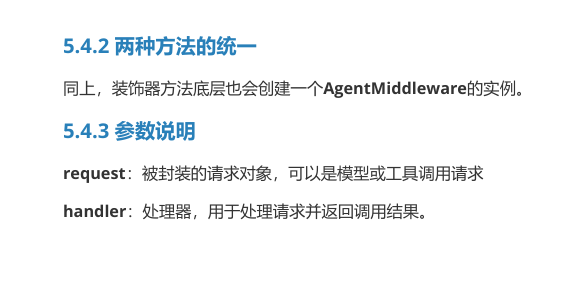
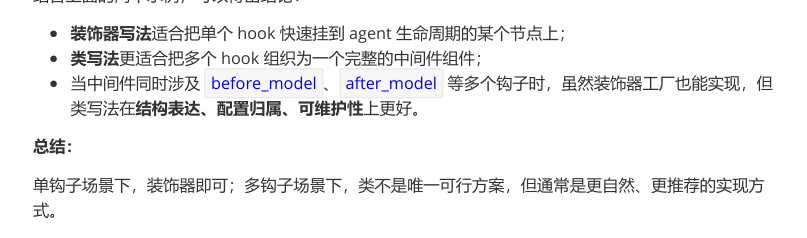

情况2：复杂配置推荐用类实现
装饰器当然也可以通过函数闭包传递参数，但在自省（运行时类型校验）、调试等方面天然不如类写法
方便。

In [30]:
from langchain.agents.middleware import before_model, AgentState, AgentMiddleware
from langgraph.runtime import Runtime
from typing import Any
from loguru import logger


# 基于类的方法
class AuditMiddleware(AgentMiddleware):
    def __init__(self, logger, threshold: int, middleware_name: str):
        self.logger = logger
        self.threshold = threshold
        self.middleware_name = middleware_name

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str,
    Any] | None:
        self.logger.info("current name: {}, threshold: {}",
                         self.middleware_name, self.threshold)
        return None


# 基于装饰器的方法，传参要通过闭包完成
def create_audit_middleware(logger, threshold: int, middleware_name: str):
    @before_model
    def audit_middleware(state: AgentState, runtime: Runtime) -> dict[str,
    Any] | None:
        logger.info("current name: {}, threshold: {}", middleware_name,
                    threshold)
        return None

    return audit_middleware


class_middle = [
    AuditMiddleware(logger=logger, threshold=5, middleware_name="short limit"),
    AuditMiddleware(logger=logger, threshold=50, middleware_name="long limit"),
]
decorator_middle = [
    create_audit_middleware(logger=logger, threshold=5,
                            middleware_name="short limit"),
    create_audit_middleware(logger=logger, threshold=50,
                            middleware_name="long limit"),
]
print("=" * 30, "-> class风格的中间件 <-", "=" * 30)
for mw in class_middle:
    print(type(mw))
print(mw.__dict__)
print("=" * 30, "-> decorator风格的中间件 <-", "=" * 30)
for mw in decorator_middle:
    print(type(mw))  # 基于类的方法
print(mw.__dict__)

============================== -> class风格的中间件 <- ==============================
<class '__main__.AuditMiddleware'>
<class '__main__.AuditMiddleware'>
{'logger': <loguru.logger handlers=[(id=0, level=10, sink=stderr)]>, 'threshold': 50, 'middleware_name': 'long limit'}
============================== -> decorator风格的中间件 <- ==============================
<class 'langchain.agents.middleware.types.audit_middleware'>
<class 'langchain.agents.middleware.types.audit_middleware'>
{}


基于类的写法可以随时打印参数信息，而基于装饰器的闭包实现则难以做到。

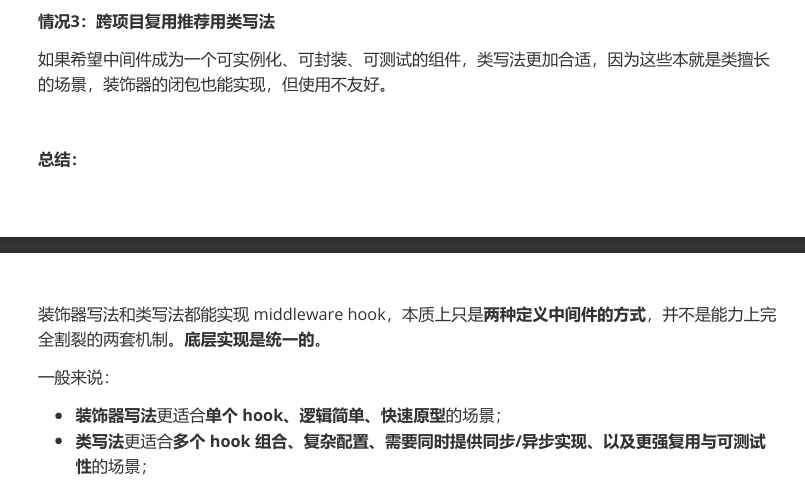